**Solubilidad del Alcafor en sCO2**
* E.O.S = PR
* Reglas de Mezclado: Van der Waals
* Parametros de interaccion binaria lij y kij -> Pero tomaremos ya los encontrados por el articulo, dado que nos faltan propiedades intensivas para poder hacer el ajuste nosotras mismas. 
* OBJ: Identificar cuando el sistema esta en equilibrio o no. 
* Datos experimentales obtenidos de:
    * Carvalho, R. N., Corazza, M. L., Cardozo-Filho, L., & Meireles, M. A. A. (2006).
          Phase Equilibrium for (Camphor + CO2), (Camphor + Propane), and (Camphor + CO2 +
          Propane). Journal of Chemical & Engineering Data, 51(3), 997–1000.
          https://nebulosa.icesi.edu.co:2144/10.1021/je0505063
    * Cálculo del flash Isotermico (T, P) — documentación de PyTher - 0. (n.d.). Retrieved from https://pyther.readthedocs.io/es/latest/flash.html

**Algoritmo**
1. Definir funcion de Peng Robinson para nuestra mezcla de interes, con parametros de interaccion binaria del articulo. -> Funcion o incluso clase  
2. Determinar los puntos de equilibrio
    * Iterar sobre Temperaturas (rango nuestro) y Presiones (rango nuestro). Especificar #moles en el sistema (sistema global composicion (nos vamos a basar en algun articulo))
    * Calcular el coeficiente de distribución Ki a partir de la relación de Wilson -> Adivinanza inicial -> Funcion
    * Calcular el valor de Beta mínimo 
    * Calcular el valor de Beta máximo
    * Calcular el promedio de beta, usando Beta minimo y Beta máximo
    * Si el promedio da por debajo de 0 o por encima de 1, a esas condiciones no se encuentra en equilibrio.
    * Resolver la ecuación de Rachford-Rice, para calcular Beta con una tolerancia de 1e-6
    * Calcular las fracciones molares del líquido xi y del vapor yi
    * Calcular los coeficientes de fugacidad para las fracciones molares del líquido xi y del vapor yi (funcion de sofi)
    * Calcular el coeficiente de distribución Ki a partir de los coeficientes de fugacidad del componente i en la mezcla de la fase vapor y líquid
    * Verificar la convergencia del sistema con una tolerancia de 1e-6 para deltaKi

In [81]:
#Imports
import numpy as np
from scipy.optimize import root
from scipy.optimize import minimize
import plotly.graph_objects as go
import chemicals
import matplotlib.pyplot as plt
from typing import Literal 

R = 8.3145e-6 #MJ/molK
# Constantes puras (Alcanfor = 1, CO2 = 2)
CAS = np.array([chemicals.search_chemical('camphor').CASs, chemicals.search_chemical('carbon dioxide').CASs])
Tc = np.array([chemicals.Tc(CAS[0]), chemicals.Tc(CAS[1])]) # K
Pc = np.array([chemicals.Pc(CAS[0])/10**6, chemicals.Pc(CAS[1])/10**6])   # MPa
omega = np.array([chemicals.omega(CAS[0]), chemicals.omega(CAS[1])])

def calc_eos_cst_pure(T):
    # PR
    b1 = 0.07780*(R*Tc[0]/Pc[0])
    a1 = 0.45724*((R*Tc[0])**2/Pc[0])*(1+(0.37464+1.54226*omega[0]-0.2699*omega[0]**2)*(1-(T/Tc[0])**0.5))**2
    b2 = 0.07780*(R*Tc[1]/Pc[1])
    a2 = 0.45724*((R*Tc[1])**2/Pc[1])*(1+(0.37464+1.54226*omega[1]-0.2699*omega[1]**2)*(1-(T/Tc[1])**0.5))**2
    return a1, b1, a2, b2

def calc_eos_cst_mix(x1, x2, k12, l12, amatriz, bs):
    bmix = bs[0]*x1**2 + 2*x1*x2*(((bs[0]+bs[1])/2)*(1-l12)) + bs[1]*x2**2
    amix = amatriz[0][0]*x1**2 + amatriz[1][0]*x2**2 + 2*amatriz[0][1]*x1*x2
    return amix, bmix

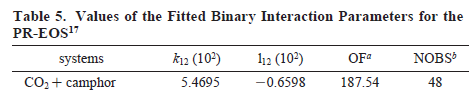

In [75]:
def PR_mix(T, P, amix, bmix, phase : Literal['liquid', 'vapor'] = 'liquid'):
    #z1 es la composicion de alcanfor en la fase que esta representando la ecuacion de Peng Robinson.
    #OBJ: Calcular el volumen de la fase
    #P = MPa
    opciones_validas = ['liquid', 'vapor']
    if phase not in opciones_validas:
        raise ValueError(
            f"phase '{phase}' no es válido. "
            f"Debe ser uno de: {opciones_validas}"
        )
    
    A = (amix * P) / ((R * T) ** 2)
    B = (bmix* P) / (R * T)
    c3 = 1.0
    c2 = -(1.0 - B)
    c1 = A - 2.0 * B - B**2
    c0 = -(A * B - B**2 - B**3)

    raices = np.roots([c3, c2, c1, c0])

    raices_reales = raices[np.isreal(raices)].real

    if len(raices_reales) == 0:
        raise RuntimeError(
            "No se encontraron raíces reales para el factor de compresibilidad Z."
        )

    if phase == "liquid":
        Z = min(raices_reales)
    else:  
        Z = max(raices_reales)

    v = (Z * R * T) / P

    return v


In [ ]:
#needed functions
def wilsonKi(P, Pci, wi, Tci, T):
    return float(np.exp(np.log(Pci/P) + 5.373*(1+wi)*(1-(Tci/T))))

def betaMax(zi, Ki):
    return (zi - 1)/(1-Ki)


def betaMin(zi, Ki):
    #si hay un error inexplicable, esta puede ser la fuente
    return (Ki*zi - 1)/(Ki - 1)

def calc_fugacity_coeff(P, T, mole_fractions, a_matrix, b_vector, a_mix, b_mix, phase_type='vapor'):
    y = np.array(mole_fractions)
    b_vector = np.array(b_vector)
    a_matrix = np.array(a_matrix)
    
    A = a_mix * P / (R**2 * T**2)
    B = b_mix * P / (R * T)

    coeff = [
        1.0,
        -(1.0 - B),
        A - 3.0 * B**2 - 2.0 * B,
        -(A * B - B**2 - B**3)
    ]

    roots = np.roots(coeff)
    roots_real = roots[np.isclose(roots.imag, 0.0, atol=1e-9)].real
    roots_real = np.sort(roots_real)

    if len(roots_real) == 0:
        raise ValueError(f"No se encontraron raíces reales para Z a T={T} K y P={P} Pa.")
    
    roots_val = [
        np.real(r) for r in roots_real
        if np.isreal(r) and np.real(r) > B
    ]

    if phase_type.lower() == 'liquid':
        Z = np.min(roots_val)   
    else:
        Z = np.max(roots_val)

    if Z <= B:
        raise ValueError(f"Raíz no física detectada (Z={Z} <= B={B}).")

    sqrt2 = np.sqrt(2.0)
    arg_log = (Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B)

    if arg_log <= 0:
        raise ValueError("Argumento logarítmico para el término de atracción es inválido.")

    suma_aj = np.dot(a_matrix, y)

    term1 = (b_vector / b_mix) * (Z - 1.0)
    term2 = -np.log(Z - B)
    term3 = -A / (2.0 * sqrt2 * B)
    term4 = (2.0 * suma_aj / a_mix) - (b_vector / b_mix)
    term5 = np.log(arg_log)

    ln_phi = term1 + term2 + term3 * term4 * term5
    phi = np.exp(ln_phi)

    return phi

def errorRR(beta, Kis, Zis):
    term1 = Zis[0] * (Kis[0] - 1) / (1 + beta * (Kis[0] - 1)) #y1 - x1
    term2 = Zis[1] * (Kis[1] - 1) / (1 + beta * (Kis[1] - 1)) #y2 - x2
    return term1 + term2 #al beta correcto, deberia dar cero. Pero da igual si los sumo o los resto.


In [103]:
k12, l12 = 5.4695e-2 , -0.6598e-2
homogeneous = {}
heterogeneous = {}

def EVL(T, P, z, Tc, Pc, omega, a_matriz, bs, tol=1e-1, max_iter=200):
    K = [wilsonKi(P, Pc[0], omega[0], Tc[0], T), wilsonKi(P, Pc[1], omega[1], Tc[1], T)]
    Bmax = betaMax(z[0], K[0])
    Bmin = betaMin(z[1], K[1])
    B0 = (Bmax + Bmin) / 2.0
    if B0 < 0 or B0 > 1:
        print("Beta not within range!")
        return None
    else:
        print("Beta within range!")
        error = 100
        for i in range(max_iter):
            # sol = root(errorRR, [0.5], args=(K, z))
            sol = minimize(errorRR, 0.5, args = (K, z), bounds= [(0,1)], tol= 1e-3)
            # print(f"minimize sols: {sol_minimize.success} , x: {sol_minimize.x}")

            if sol.success:
                print("success!")
                # beta = float(sol.x[0])
                beta = float(sol.x[0])
                if 0.0 <= beta <= 1.0:
                    beta = sol.x[0] 
                    y1 = K[0]*z[0]/(1-beta + beta*K[0])
                    x1 = z[0]/(1-beta + beta*K[0])
                    y2 = K[1]*z[1]/(1-beta + beta*K[1])
                    x2 = z[1]/(1-beta + beta*K[1])
                    amixV, bmixV = calc_eos_cst_mix(y1, y2, k12, l12, a_matriz, bs)
                    amixL, bmixL = calc_eos_cst_mix(x1, x2, k12, l12, a_matriz, bs)
                    phiL = calc_fugacity_coeff(P, T, [x1, x2], a_matriz, bs, amixL, bmixL, phase_type='liquid')
                    phiV = calc_fugacity_coeff(P, T, [y1,y2], a_matriz, bs, amixV, bmixV, phase_type='vapor') 
                    Ks = phiL/phiV

                    delta_K = np.linalg.norm(Ks - K)
                    if delta_K < tol:
                        print("return not None")
                        return [x1,x2], [y1,y2], beta 
                        
                    K = Ks
                
                else:    
                    return None
        
            else:
                return None
                    

In [104]:
Ts = np.linspace(298.15, (60+273.15), 1000)
Ps = np.linspace(Pc[1], 1300/145, 3)
z1 = 0.0015 #
z2 = 1 - z1
x_camphor = {}
y_camphor = {}
Teq = {}
for P in Ps:
        Teq[P] = []
        for T in Ts:                        
            a1, b1, a2, b2 = calc_eos_cst_pure(T)
            a12 = np.sqrt(a1 * a2) * (1.0 - k12)
            a_matriz = [[a1, a12],[a12,a2]]
            bs = [b1, b2]
            result = EVL(T, P, [z1, z2], Tc, Pc, omega, a_matriz, bs, tol = 1e-6, max_iter=200)
            if result is not None:
                print('*')
                heterogeneous[P] = T
                x_camphor[P] = []
                y_camphor[P] = []
                Teq[P] = []
                x, y, beta = result
                x_camphor[P].append(x[0])
                y_camphor[P].append(y[0])
                Teq[P].append(T)
                
            else:
                homogeneous[P] = T  
                print('O')

print(f"x_camphor = {x_camphor} , \n y_cmaphor = {y_camphor}, \n Teq [P:array[Teqs]] = {Teq}, \n heterogeneous [P:Teq]= {heterogeneous}, \n homogeneous [P:Teq]= {homogeneous}")


plt.figure(figsize=(8, 6))
for P in Ps:   
    if len(Teq[P]) > 0:
        plt.plot(x_camphor[P], Teq[P], 'b-', label=f'x1,{P}')
        plt.plot(y_camphor[P], Teq[P], 'r-', label=f'y1,{P}')
plt.xlabel('Fracción Molar de Alcanfor ($x_1, y_1$)')
plt.ylabel('Temperatura (K)')
plt.title(f'Diagrama de Equilibrio T-x-y MPa')
plt.grid(True)
plt.legend()
plt.show()

Beta within range!
success!
success!
success!


C:\Users\premz\AppData\Local\Temp/ipykernel_392/824285704.py:68: RuntimeWarning: divide by zero encountered in true_divide
  term1 = Zis[0] * (Kis[0] - 1) / (1 + beta * (Kis[0] - 1)) #y1 - x1


ValueError: zero-size array to reduction operation minimum which has no identity

**Calculo de condiciones Experimentales** 

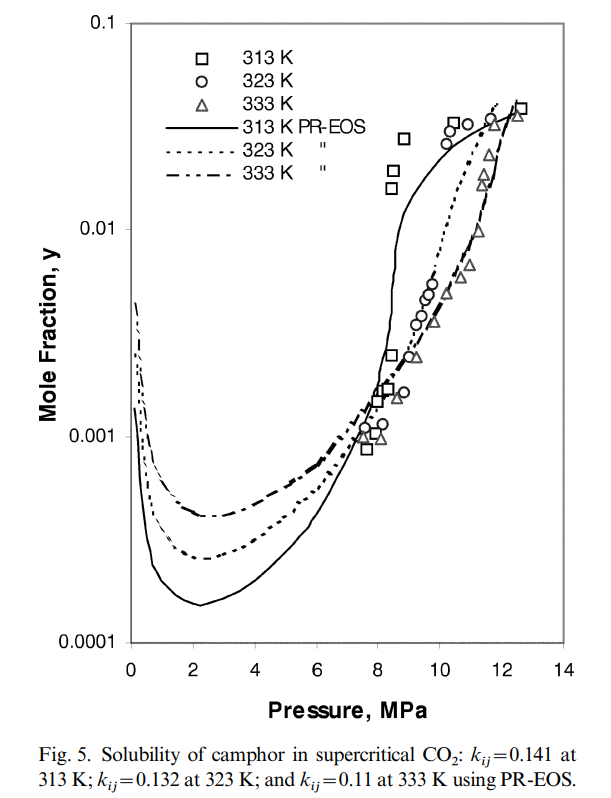

In [ ]:
#OBJ: Calcular cuanto CO2 es necesario en gramos. 
#Escogimos una P = 8.5 MPa y una T inicial de 313 K.
#Entonces, tenemos un volumen fijo tambien, la idea es determinar la fraccion de sCO2 necesaria. Y conocemos la de alcanfor que es de 

V = 20e-6 #m^3

#Proceso: Obtener volumen especifico de la mezcla, luego dividir volumen total sobre volumen en 
# especifico, y asi obtenemos el numero de moles totales. Luego eso lo multiplicamos por las fracciones, 
# y luego a cada fraccion por su masa molar, y asi obtenemos las masas requeridas de cada sustancia para estar en 
# una fase homogenea en eas condiciones. Y en base a la grafica, sabemos que al aumentar la temepratura, se formaran dos fases. 
#Usaremos losparametros de interaccion binaria del articulo del cual la grafica es permaneciente a 

kij_313K = 0.132
lij_313K = 0

z1 = 1.92e-2 #Estimado con gemini, aqui entre nos
z2 = 1- z1

z = [z1, z2]


a1, b1, a2, b2 = calc_eos_cst_pure(T)
a12 = np.sqrt(a1 * a2) * (1.0 - k12)
a_matriz = [[a1, a12],[a12,a2]]
bs = [b1, b2]

amixV, bmixV = calc_eos_cst_mix(z[0], z[1], k12, l12, a_matriz, bs)

# def PR_mix(T, P, amix, bmix, phase : Literal['liquid', 'vapor'] = 'liquid'):

v = PR_mix(313, 8.5, amixV, bmixV, phase = 'vapor')

moles = V/v

mW = [chemicals.search_chemical('camphor').MW, chemicals.search_chemical('carbon dioxide').MW]

m= [moles*z[0]*mW[0], moles*z[1]*mW[1]]

print(f"Mass of camphor: {m[0]} g \nMass of CO2: {m[1]} g")


Mass of camphor: 1.840460655929611 g 
Mass of CO2: 27.179542338816013 g
